In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
import numpy as np

In [35]:
meal_info = pd.read_csv("C:/Users/aless/Downloads/meal_info.csv").set_index('meal_id')
meal_info.head()

,category,cuisine
meal_id,,
1885,Beverages,Thai
1993,Beverages,Thai
2539,Beverages,Thai
1248,Beverages,Indian
2631,Beverages,Indian


In [36]:
center_info = pd.read_csv("C:/Users/aless/Downloads/fulfilment_center_info.csv").set_index('center_id')
center_info.head()

,city_code,region_code,center_type,op_area
center_id,,,,
11,679,56,TYPE_A,3.7
13,590,56,TYPE_B,6.7
124,590,56,TYPE_C,4.0
66,648,34,TYPE_A,4.1
94,632,34,TYPE_C,3.6


In [ ]:
raw_data = pd.read_csv("C:/Users/aless/Downloads/train.csv")
raw_data[['center_id','meal_id']] = raw_data[['center_id','meal_id']].astype(str)
raw_data['product'] = raw_data.apply(lambda row: row.center_id + '_' + row.meal_id, axis=1)

In [13]:
raw_data.head()

,id,week,center_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders
0,1379560,1,55,1885,136.83,152.29,0,0,177
1,1466964,1,55,1993,136.83,135.83,0,0,270
2,1346989,1,55,2539,134.86,135.86,0,0,189
3,1338232,1,55,2139,339.50,437.53,0,0,54
4,1448490,1,55,2631,243.50,242.50,0,0,40


In [17]:
raw_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 456548 entries, 0 to 456547
Data columns (total 9 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   id                     456548 non-null  int64  
 1   week                   456548 non-null  int64  
 2   center_id              456548 non-null  object 
 3   meal_id                456548 non-null  object 
 4   checkout_price         456548 non-null  float64
 5   base_price             456548 non-null  float64
 6   emailer_for_promotion  456548 non-null  int64  
 7   homepage_featured      456548 non-null  int64  
 8   num_orders             456548 non-null  int64  
dtypes: float64(2), int64(5), object(2)
memory usage: 31.3+ MB


In [30]:
data = raw_data.pivot_table(index='week', columns='product', values='num_orders')
data = data.dropna(axis=1)
data.head()

product,101_1062,101_1109,101_1207,101_1727,101_1754,101_1778,101_1885,101_1962,101_1971,101_1993,...,99_1885,99_1962,99_1971,99_1993,99_2290,99_2539,99_2577,99_2581,99_2707,99_2826
week,,,,,,,,,,,,,,,,,,,,,
1,379.0,1255.0,1269.0,366.0,337.0,283.0,447.0,364.0,744.0,593.0,...,931.0,512.0,270.0,904.0,431.0,203.0,26.0,323.0,1256.0,635.0
2,270.0,445.0,959.0,339.0,242.0,297.0,554.0,339.0,701.0,501.0,...,796.0,418.0,621.0,580.0,258.0,364.0,53.0,312.0,865.0,405.0
3,285.0,447.0,1214.0,296.0,324.0,216.0,338.0,122.0,256.0,663.0,...,865.0,121.0,121.0,688.0,352.0,325.0,42.0,95.0,1106.0,608.0
4,269.0,474.0,1068.0,514.0,350.0,338.0,406.0,162.0,189.0,647.0,...,2364.0,161.0,121.0,621.0,337.0,175.0,109.0,150.0,1242.0,595.0
5,447.0,514.0,499.0,1580.0,204.0,337.0,365.0,161.0,149.0,607.0,...,1957.0,175.0,42.0,593.0,12137.0,54.0,107.0,94.0,904.0,377.0


In [53]:
data.min().sort_values()

product
97_2867      13.0
27_2640      13.0
93_1878      13.0
93_1207      13.0
106_1230     13.0
            ...  
27_1885     662.0
67_1885     702.0
43_1885     877.0
174_1885    878.0
13_1885     879.0
Length: 1247, dtype: float64

In [46]:
top_sellers = data.mean().sort_values(ascending=False)[-10:]
top_sellers

product
149_2631    91.027586
51_2494     90.841379
86_1438     86.517241
68_1207     85.386207
32_1525     84.565517
80_2760     82.910345
64_1525     81.786207
91_1993     79.820690
29_2640     78.275862
39_2640     72.068966
dtype: float64

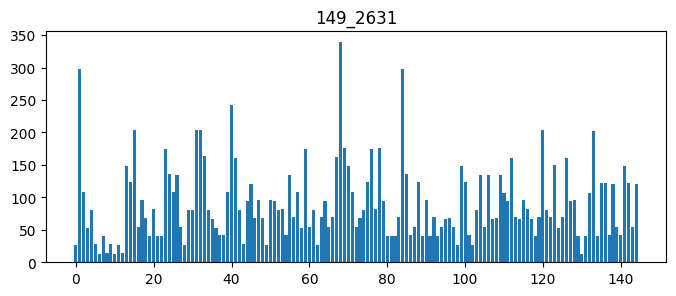

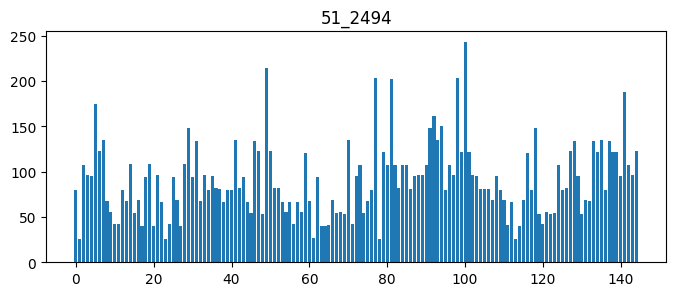

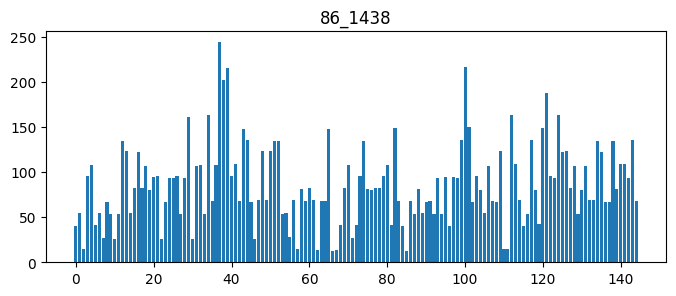

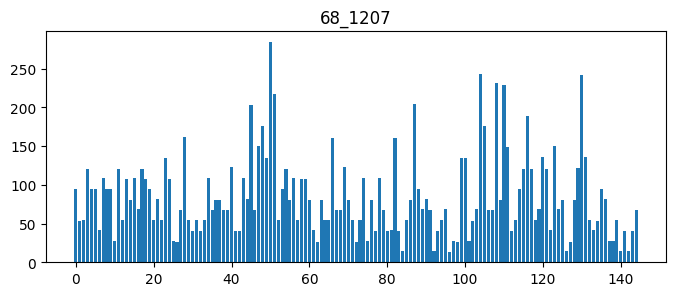

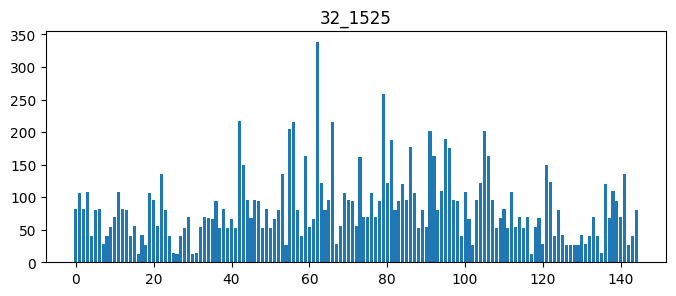

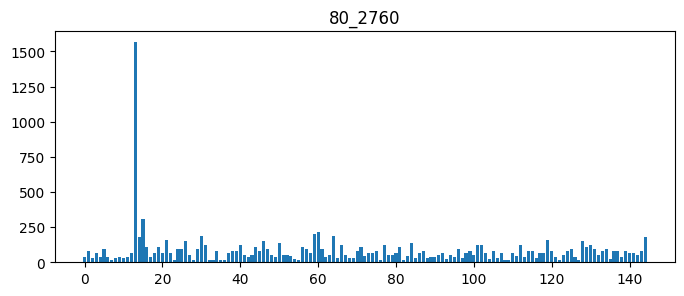

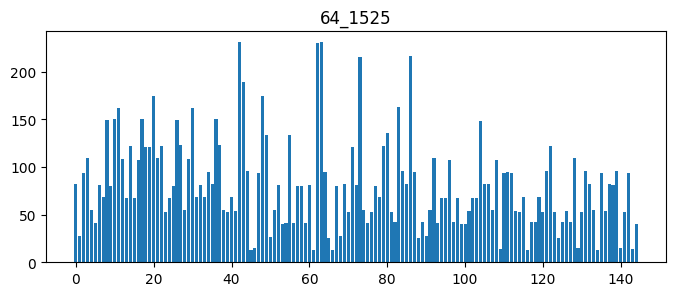

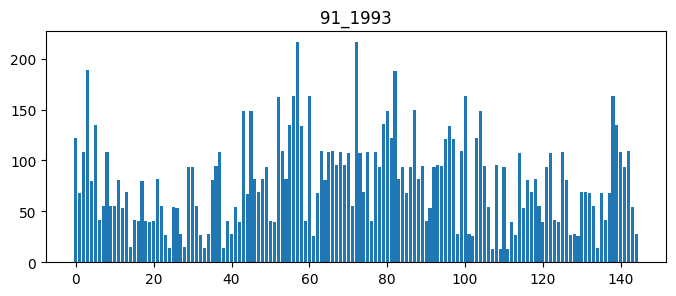

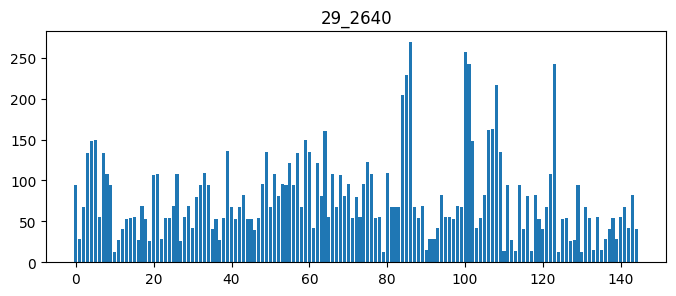

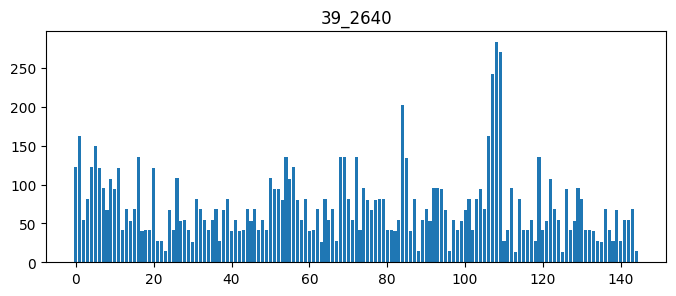

In [47]:
for i in range(top_sellers.shape[0]):
    
    fig, ax = plt.subplots(figsize=(8, 3))
    
    ax.bar(np.arange(data.shape[0]), data[top_sellers.index[i]])
    ax.set_title(top_sellers.index[i])
    
    plt.show()

In [31]:
data.shape

(145, 1247)

In [14]:
raw_data.shape

(456548, 9)

In [5]:
raw_data.describe()

,id,week,center_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders
count,4.565480e+05,456548.000000,456548.000000,456548.000000,456548.000000,456548.000000,456548.000000,456548.00000,456548.000000
mean,1.250096e+06,74.768771,82.105796,2024.337458,332.238933,354.156627,0.081152,0.10920,261.872760
std,1.443548e+05,41.524956,45.975046,547.420920,152.939723,160.715914,0.273069,0.31189,395.922798
min,1.000000e+06,1.000000,10.000000,1062.000000,2.970000,55.350000,0.000000,0.00000,13.000000
25%,1.124999e+06,39.000000,43.000000,1558.000000,228.950000,243.500000,0.000000,0.00000,54.000000
50%,1.250184e+06,76.000000,76.000000,1993.000000,296.820000,310.460000,0.000000,0.00000,136.000000
75%,1.375140e+06,111.000000,110.000000,2539.000000,445.230000,458.870000,0.000000,0.00000,324.000000
max,1.499999e+06,145.000000,186.000000,2956.000000,866.270000,866.270000,1.000000,1.00000,24299.000000


In [7]:
data.meal_id.unique().shape

(51,)

In [8]:
data.center_id.unique().shape

(77,)

In [9]:
data[['meal_id', 'center_id']].drop_duplicates().shape[0]

3597

In [11]:
3597*145

521565